In [ ]:
# Part 2: Computer Vision Problem Formulation and CNN Prototype

## Objective

#The objective of this assignment is to formulate a computer vision problem and develop a CNN model capable of identifying manufacturing surface defects from images.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing import image

In [ ]:
import os

os.makedirs(
    "results",
    exist_ok=True
)

os.makedirs(
    "sample_predictions",
    exist_ok=True
)

In [ ]:
# Task 1: Problem Identification

#The dataset contains images categorized into four predefined defect classes: normal, scratch, dent, and stain.

#This problem is identified as an image classification task because each image belongs to exactly one category. The objective is to assign a class label to an entire image rather than detect object locations or segment pixels.

In [ ]:
# Task 2: Dataset Exploration

#Dataset exploration was conducted to understand class distribution and image characteristics.

In [ ]:
labels=pd.read_csv(
"labels.csv"
)

labels.head()

,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


In [ ]:
print(
labels["class"].nunique()
)

4


In [ ]:
#The number of unique classes was inspected.

In [ ]:
labels['class'].value_counts()

,count
class,
normal,120
scratch,120
dent,120
stain,120


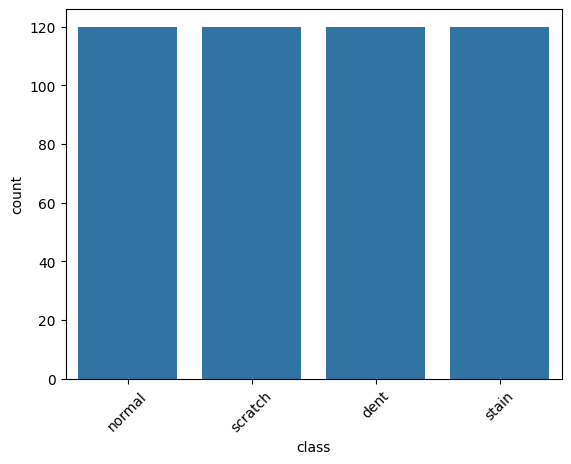

In [ ]:
sns.countplot(
x='class',
data=labels
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
#Class distribution was analyzed to identify potential imbalance.

In [ ]:
classes=['normal',
         'scratch',
         'dent',
         'stain']

plt.figure(figsize=(12,8))

for i,class_name in enumerate(classes):

    path=f"images/{class_name}"

    file=os.listdir(path)[0]

    img=plt.imread(
        f"{path}/{file}"
    )

    plt.subplot(
        2,
        2,
        i+1
    )

    plt.imshow(img)

    plt.title(class_name)

plt.show()

In [ ]:
#Representative images from each category were displayed for visual inspection.

In [ ]:
img.shape

In [ ]:
#Image dimensions were examined to determine preprocessing requirements.

In [ ]:
# Task 3: Image Preprocessing

#Images were resized and normalized before training.

In [ ]:
train_datagen=ImageDataGenerator(

rescale=1./255,

validation_split=.20,

rotation_range=15,

zoom_range=.2,

horizontal_flip=True

)

In [ ]:
#Data augmentation was applied to increase variation and reduce overfitting.

In [ ]:
train_generator=train_datagen.flow_from_directory(

"images",

target_size=(128,128),

batch_size=32,

class_mode='categorical',

subset='training'

)

In [ ]:
validation_generator=train_datagen.flow_from_directory(

"images",

target_size=(128,128),

batch_size=32,

class_mode='categorical',

subset='validation'

)

In [ ]:
# Task 4: CNN Model Creation

In [9]:
model=Sequential()

In [10]:
model.add(

Conv2D(

32,

(3,3),

activation='relu',

input_shape=(128,128,3)

)

)

model.add(
MaxPooling2D(2,2)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.add(

Conv2D(

64,

(3,3),

activation='relu'

)

)

model.add(
MaxPooling2D(2,2)
)

In [12]:
model.add(
Flatten()
)

In [13]:
model.add(

Dense(
128,
activation='relu'
)

)

In [14]:
model.add(

Dense(
4,
activation='softmax'
)

)

In [15]:
model.compile(

optimizer='adam',

loss='categorical_crossentropy',

metrics=['accuracy']

)

In [ ]:
#The architecture consists of convolution, pooling, flattening, and dense layers.

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history=model.fit(

train_generator,

epochs=10,

validation_data=validation_generator

)

NameError: name 'train_generator' is not defined

In [18]:
plt.figure()

plt.plot(
history.history['accuracy']
)

plt.plot(
history.history['val_accuracy']
)

plt.legend(
['Training',
'Validation']
)

plt.title(
"Accuracy Curves"
)

plt.savefig(
"results/accuracy_loss_curves.png"
)

plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure()

plt.plot(
history.history['loss']
)

plt.plot(
history.history['val_loss']
)

plt.legend(
['Training',
'Validation']
)

plt.title(
"Loss Curves"
)

plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

In [20]:
pred=model.predict(
validation_generator
)

pred=np.argmax(
pred,
axis=1
)

NameError: name 'validation_generator' is not defined

In [21]:
true=validation_generator.classes

NameError: name 'validation_generator' is not defined

In [22]:
cm=confusion_matrix(
true,
pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.savefig(
"results/confusion_matrix.png"
)

plt.show()

NameError: name 'true' is not defined

In [ ]:
#The confusion matrix was used to analyze prediction quality across classes.

In [23]:
plt.figure(figsize=(12,8))

for i in range(4):

    x,y=next(validation_generator)

    plt.subplot(
    2,
    2,
    i+1
    )

    plt.imshow(x[0])

    pred=model.predict(
    x
    )

    predicted=np.argmax(
    pred[0]
    )

    labels=list(
    validation_generator.class_indices.keys()
    )

    plt.title(
    labels[predicted]
    )

plt.savefig(
"sample_predictions/prediction_outputs.png"
)

plt.show()

NameError: name 'validation_generator' is not defined

<Figure size 1200x800 with 0 Axes>

In [24]:
plt.figure(figsize=(12,8))

for i in range(4):

    x,y=next(validation_generator)

    plt.subplot(
    2,
    2,
    i+1
    )

    plt.imshow(x[0])

    pred=model.predict(
    x
    )

    predicted=np.argmax(
    pred[0]
    )

    labels=list(
    validation_generator.class_indices.keys()
    )

    plt.title(
    labels[predicted]
    )

plt.savefig(
"sample_predictions/prediction_outputs.png"
)

plt.show()

NameError: name 'validation_generator' is not defined

<Figure size 1200x800 with 0 Axes>

# Task 6: CNN Concepts

### What is convolution?

Convolution extracts visual features such as edges and patterns using filters.

### Why is pooling used?

Pooling reduces image dimensions and computational complexity.

### Why ReLU?

ReLU introduces non-linearity and reduces vanishing gradient issues.

### Why CNN instead of feed-forward networks?

CNNs preserve spatial information and automatically learn image features.

# Task 7: Business Use Case

Manufacturing quality inspection commonly uses computer vision systems to detect defects during production.

A CNN-based system can automatically identify scratches, dents, and stains on products, reducing manual inspection effort and improving production quality.